**Polycystic Ovary Syndrome (PCOS) Prediction
bold text**

In [1]:
from google.colab import userdata
github_token = userdata.get("GITHUB_TOKEN")

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
#import data
pcos_df = pd.read_csv('/content/drive/MyDrive/datasets/PCOS.csv')
pcos_df.head(3)
pcos_df.info()
print("Dataset shape :",pcos_df.shape)
pcos_df.isna().sum().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 45 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sl. No                  541 non-null    int64  
 1   Patient File No.        541 non-null    int64  
 2   PCOS (Y/N)              541 non-null    int64  
 3    Age (yrs)              541 non-null    int64  
 4   Weight (Kg)             541 non-null    float64
 5   Height(Cm)              541 non-null    float64
 6   BMI                     541 non-null    float64
 7   Blood Group             541 non-null    int64  
 8   Pulse rate(bpm)         541 non-null    int64  
 9   RR (breaths/min)        541 non-null    int64  
 10  Hb(g/dl)                541 non-null    float64
 11  Cycle(R/I)              541 non-null    int64  
 12  Cycle length(days)      541 non-null    int64  
 13  Marraige Status (Yrs)   540 non-null    float64
 14  Pregnant(Y/N)           541 non-null    in

np.int64(541)

In [4]:
# Performing EDA
pcos_df = pcos_df.drop(columns = ['Sl. No','Patient File No.','Unnamed: 44'])
pcos_df.head(2)


,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),Hb(g/dl),Cycle(R/I),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
0,0,28,44.6,152.0,19.300000,15,78,22,10.48,2,...,0,1.0,0,110,80,3,3,18.0,18.0,8.5
1,0,36,65.0,161.5,24.921163,15,74,20,11.70,2,...,0,0.0,0,120,70,3,5,15.0,14.0,3.7


In [5]:
nan_rows = pcos_df[pcos_df.isna().any(axis=1)]
print(nan_rows)

     PCOS (Y/N)   Age (yrs)  Weight (Kg)  Height(Cm)    BMI  Blood Group  \
156           0          27         53.2        158.0  21.3           13   
458           1          36         66.0        162.0  25.1           15   

     Pulse rate(bpm)   RR (breaths/min)  Hb(g/dl)  Cycle(R/I)  ...  \
156                72                22      10.5           4  ...   
458                72                20      11.0           4  ...   

     Pimples(Y/N)  Fast food (Y/N)  Reg.Exercise(Y/N)  BP _Systolic (mmHg)  \
156             0              NaN                  1                  120   
458             0              0.0                  0                  120   

     BP _Diastolic (mmHg) Follicle No. (L)  Follicle No. (R)  \
156                    70                5                 7   
458                    80               14                 5   

     Avg. F size (L) (mm)  Avg. F size (R) (mm)  Endometrium (mm)  
156                  11.0                  13.0              11.

In [6]:
pcos_df['Marraige Status (Yrs)']= pcos_df['Marraige Status (Yrs)'].fillna(pcos_df['Marraige Status (Yrs)'].median())
pcos_df['Fast food (Y/N)']= pcos_df['Fast food (Y/N)'].fillna(pcos_df['Fast food (Y/N)'].median())
pcos_df.isna().sum()

,0
PCOS (Y/N),0
Age (yrs),0
Weight (Kg),0
Height(Cm),0
BMI,0
Blood Group,0
Pulse rate(bpm),0
RR (breaths/min),0
Hb(g/dl),0
Cycle(R/I),0


In [7]:
pcos_df.select_dtypes(include= ['object']).head()

,II beta-HCG(mIU/mL),AMH(ng/mL)
0,1.99,2.07
1,1.99,1.53
2,494.08,6.63
3,1.99,1.22
4,801.45,2.26


In [8]:
pcos_df['II    beta-HCG(mIU/mL)'] = pd.to_numeric(pcos_df['II    beta-HCG(mIU/mL)'], errors = 'coerce')
pcos_df['AMH(ng/mL)'] = pd.to_numeric(pcos_df['AMH(ng/mL)'], errors = 'coerce')

pcos_df.columns = pcos_df.columns.str.strip()

In [9]:
pcos_df['II    beta-HCG(mIU/mL)'] = pcos_df['II    beta-HCG(mIU/mL)'].fillna(pcos_df['II    beta-HCG(mIU/mL)'].median())
pcos_df['AMH(ng/mL)'] = pcos_df['AMH(ng/mL)'].fillna(pcos_df['AMH(ng/mL)'].median())
pcos_df.isna().sum()[pcos_df.isna().sum()>0]

,0


In [10]:
pcos_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 42 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   PCOS (Y/N)              541 non-null    int64  
 1   Age (yrs)               541 non-null    int64  
 2   Weight (Kg)             541 non-null    float64
 3   Height(Cm)              541 non-null    float64
 4   BMI                     541 non-null    float64
 5   Blood Group             541 non-null    int64  
 6   Pulse rate(bpm)         541 non-null    int64  
 7   RR (breaths/min)        541 non-null    int64  
 8   Hb(g/dl)                541 non-null    float64
 9   Cycle(R/I)              541 non-null    int64  
 10  Cycle length(days)      541 non-null    int64  
 11  Marraige Status (Yrs)   541 non-null    float64
 12  Pregnant(Y/N)           541 non-null    int64  
 13  No. of aborptions       541 non-null    int64  
 14  I   beta-HCG(mIU/mL)    541 non-null    fl

In [11]:
print(pcos_df.duplicated().sum())
pcos_df.drop_duplicates()

0


,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),Hb(g/dl),Cycle(R/I),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
0,0,28,44.6,152.000,19.300000,15,78,22,10.48,2,...,0,1.0,0,110,80,3,3,18.0,18.0,8.5
1,0,36,65.0,161.500,24.921163,15,74,20,11.70,2,...,0,0.0,0,120,70,3,5,15.0,14.0,3.7
2,1,33,68.8,165.000,25.270891,11,72,18,11.80,2,...,1,1.0,0,120,80,13,15,18.0,20.0,10.0
3,0,37,65.0,148.000,29.674945,13,72,20,12.00,2,...,0,0.0,0,120,70,2,2,15.0,14.0,7.5
4,0,25,52.0,161.000,20.060954,11,72,18,10.00,2,...,0,0.0,0,120,80,3,4,16.0,14.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
536,0,35,50.0,164.592,18.500000,17,72,16,11.00,2,...,0,0.0,0,110,70,1,0,17.5,10.0,6.7
537,0,30,63.2,158.000,25.300000,15,72,18,10.80,2,...,0,0.0,0,110,70,9,7,19.0,18.0,8.2
538,0,36,54.0,152.000,23.400000,13,74,20,10.80,2,...,0,0.0,0,110,80,1,0,18.0,9.0,7.3
539,0,27,50.0,150.000,22.200000,15,74,20,12.00,4,...,1,0.0,0,110,70,7,6,18.0,16.0,11.5


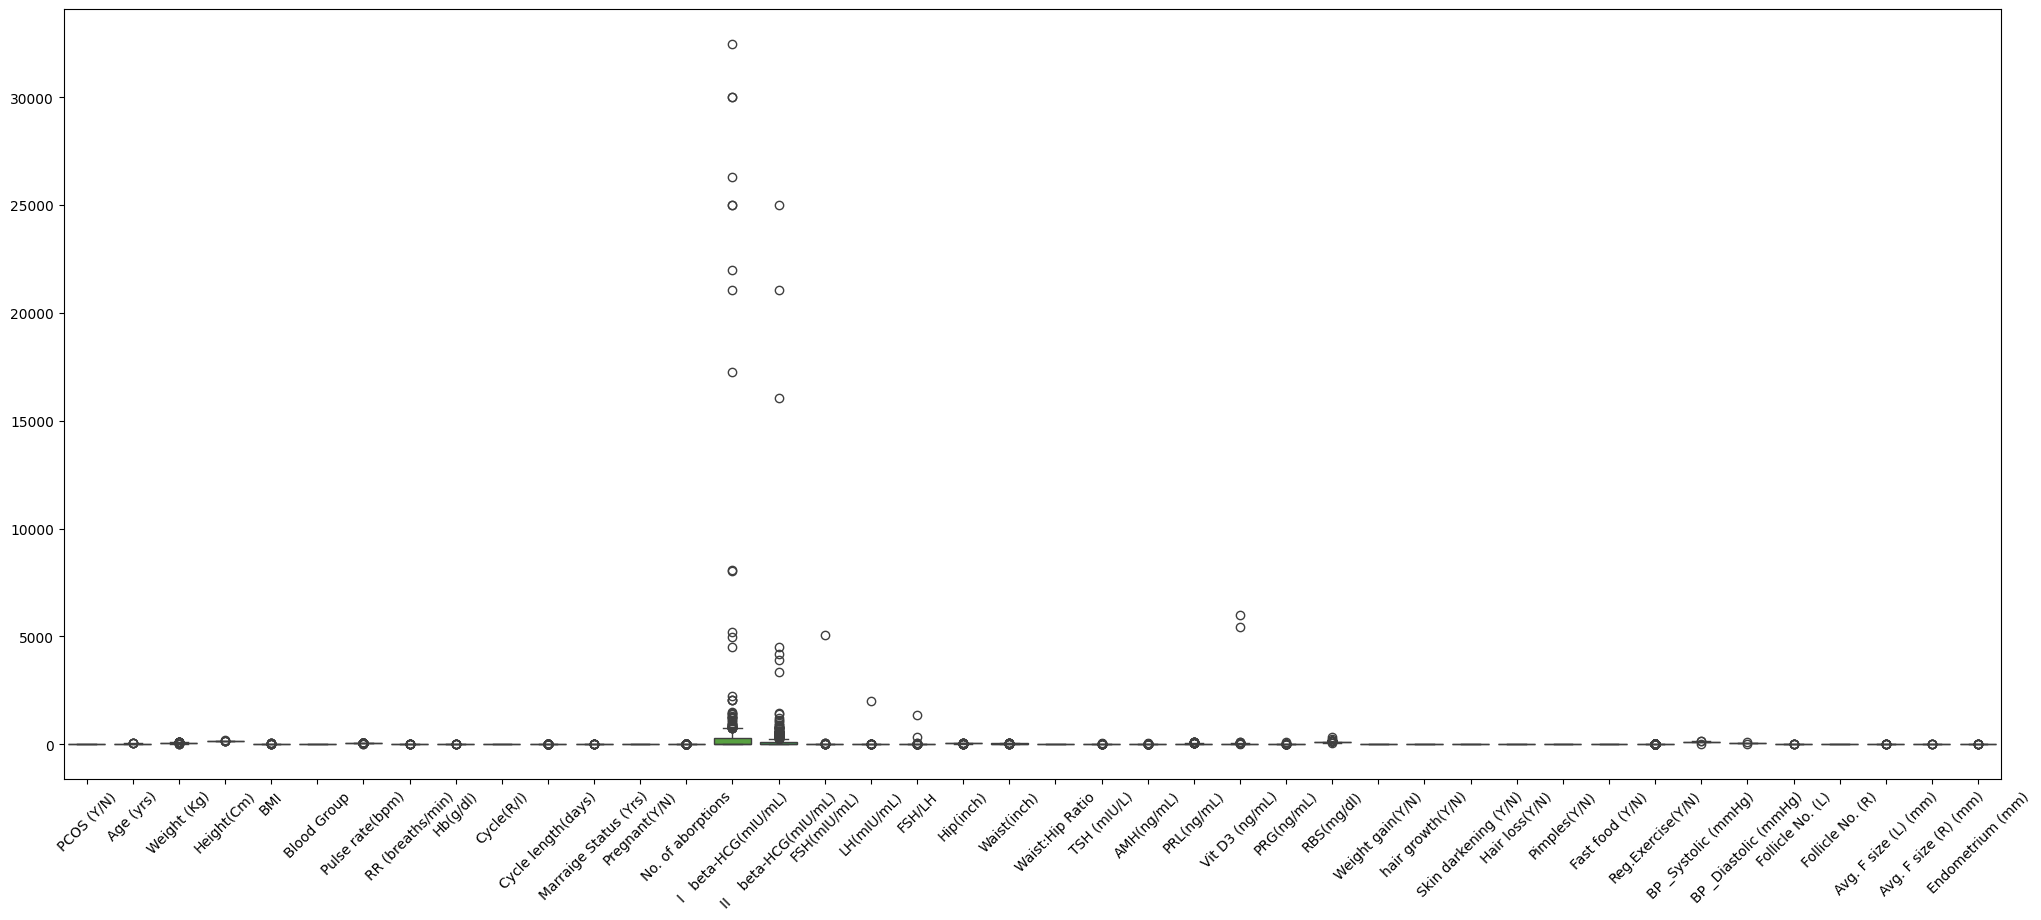

In [12]:
# Detect & Handle Outliers
# Visualize numerical distributions to spot extreme outliers
plt.figure(figsize=(25, 10))
sns.boxplot(data=pcos_df)
plt.xticks(rotation=45)
plt.show()

In [13]:
# Apply Winsorization to specific columns with extreme values
cols_to_winsorize = ['II    beta-HCG(mIU/mL)', 'No. of aborptions']

#capping extreme high values at the 99th percentile ceiling.
for col in cols_to_winsorize:
    upper_limit = pcos_df[col].quantile(0.99)
    pcos_df[col] = np.where(pcos_df[col] > upper_limit, upper_limit, pcos_df[col])

In [14]:
#splitting and scaling data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

from sklearn.model_selection import train_test_split

x = pcos_df.drop(columns = ['PCOS (Y/N)'])
y = pcos_df['PCOS (Y/N)']

x_train, x_test, y_train, y_test = train_test_split(
    x,y, test_size = 0.2, random_state= 42)

x_train_scaled = pd.DataFrame(scaler.fit_transform(x_train), columns = x.columns)
x_test_scaled = pd.DataFrame(scaler.transform(x_test), columns = x.columns)

In [16]:
#since the class is a little imbalance, we use smote
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state = 42)
x_train_resampled, y_train_resampled = smote.fit_resample(x_train_scaled, y_train)

PCOS (Y/N)
1    0.5
0    0.5
Name: proportion, dtype: float64


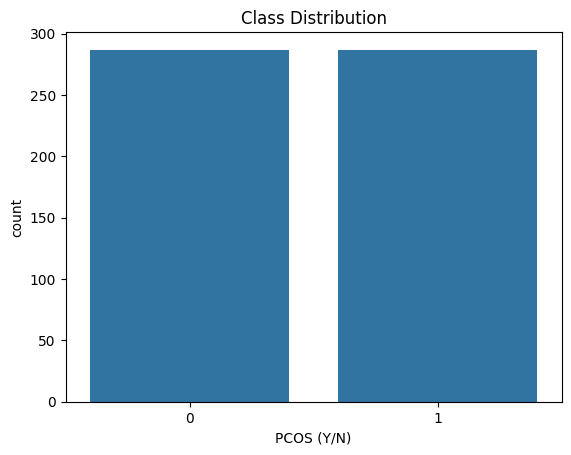

In [17]:
print(y_train_resampled.value_counts(normalize=True))
sns.countplot(x=y_train_resampled)
plt.title("Class Distribution")
plt.show()

In [19]:
%cd /content/drive/

drive  sample_data
